In [ ]:
#Conectar o google drive ao notebook

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


Criação da estrutura do projeto no Drive

In [3]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/portfolio/shopmais-churn-eda")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
REPORTS_DIR = PROJECT_DIR / "reports"
SRC_DIR = PROJECT_DIR / "src"
IMAGES_DIR = PROJECT_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Pasta de imagens:", IMAGES_DIR)

for folder in [RAW_DIR, PROCESSED_DIR, NOTEBOOKS_DIR, REPORTS_DIR, SRC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Projeto criado em:")
print(PROJECT_DIR)

print("\nPastas criadas:")
for folder in [RAW_DIR, PROCESSED_DIR, NOTEBOOKS_DIR, REPORTS_DIR, SRC_DIR]:
    print("-", folder)

Projeto criado em:
/content/drive/MyDrive/portfolio/shopmais-churn-eda

Pastas criadas:
- /content/drive/MyDrive/portfolio/shopmais-churn-eda/data/raw
- /content/drive/MyDrive/portfolio/shopmais-churn-eda/data/processed
- /content/drive/MyDrive/portfolio/shopmais-churn-eda/notebooks
- /content/drive/MyDrive/portfolio/shopmais-churn-eda/reports
- /content/drive/MyDrive/portfolio/shopmais-churn-eda/src


Bibliotecas necessárias para o projeto.

In [4]:
!pip install -q kaggle openpyxl pandas numpy matplotlib scikit-learn

Baixar a base direto do Kaggle

Agora vamos baixar a base pública de churn em e-commerce escolhida para o projeto. Essa base é adequada porque contém variáveis de clientes, pedidos, reclamações, satisfação, cashback e a variável

In [6]:
import os

# 1. Define o  caminho de dados
os.environ["RAW_DIR"] = str(RAW_DIR)


os.environ["KAGGLE_USERNAME"] = "usuário kaggle" #nome de usuário ocultado por motivos de segurança
os.environ["KAGGLE_KEY"] = "Token kaggle" #token pessoal também foi ocultado


!kaggle datasets download -d ankitverma2010/ecommerce-customer-churn-analysis-and-prediction -p "$RAW_DIR" --unzip

Dataset URL: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction
License(s): CC-BY-NC-SA-4.0
100% 532k/532k [00:00<00:00, 32.4MB/s]



In [7]:
raw_files = list(RAW_DIR.glob("*"))

print("Arquivos encontrados em data/raw:")
for file in raw_files:
    print("-", file.name)


Arquivos encontrados em data/raw:
- E Commerce Dataset.xlsx


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

raw_files = list(RAW_DIR.glob("*"))

if not raw_files:
    raise FileNotFoundError("Nenhum arquivo encontrado em data/raw.")

data_path = raw_files[0]

print("Arquivo selecionado:", data_path.name)

if data_path.suffix.lower() in [".xlsx", ".xls"]:
    excel_file = pd.ExcelFile(data_path)
    print("Abas encontradas:", excel_file.sheet_names)

    if "E Comm" in excel_file.sheet_names:
        sheet_name = "E Comm"
    else:
        sheet_name = excel_file.sheet_names[-1]

    print("Aba utilizada:", sheet_name)
    df = pd.read_excel(data_path, sheet_name=sheet_name)

elif data_path.suffix.lower() == ".csv":
    df = pd.read_csv(data_path)

else:
    raise ValueError("Formato de arquivo não suportado.")

print("Dimensão da base:", df.shape)
df.head()

Arquivo selecionado: E Commerce Dataset.xlsx
Abas encontradas: ['Data Dict', 'E Comm']
Aba utilizada: E Comm
Dimensão da base: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93
1,50002,1,NaN,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90
2,50003,1,NaN,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28
3,50004,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07
4,50005,1,0.00,Phone,1,12.00,CC,Male,NaN,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60


Padronizar nome das colunas

In [9]:
def standardize_column_name(column):
    column = str(column).strip()
    column = re.sub(r"(?<=[a-z0-9])(?=[A-Z])", "_", column)
    column = column.lower()
    column = re.sub(r"[^a-z0-9]+", "_", column)
    column = column.strip("_")
    return column


df.columns = [standardize_column_name(col) for col in df.columns]

rename_map = {
    "customer_i_d": "customer_id",
    "customer_id": "customer_id",
    "prefered_order_cat": "preferred_order_category",
    "preferred_order_cat": "preferred_order_category",
    "order_amount_hike_fromlast_year": "order_amount_hike_from_last_year",
    "day_since_last_order": "days_since_last_order",
    "hour_spend_on_app": "hours_spent_on_app",
    "number_of_device_registered": "number_of_devices_registered",
    "coupon_used": "coupons_used",
    "complain": "complained",
    "warehouse_to_home": "warehouse_to_home_km"
}

df = df.rename(columns=rename_map)

df.columns.tolist()

['customer_id',
 'churn',
 'tenure',
 'preferred_login_device',
 'city_tier',
 'warehouse_to_home_km',
 'preferred_payment_mode',
 'gender',
 'hours_spent_on_app',
 'number_of_devices_registered',
 'preferred_order_category',
 'satisfaction_score',
 'marital_status',
 'number_of_address',
 'complained',
 'order_amount_hike_from_last_year',
 'coupons_used',
 'order_count',
 'days_since_last_order',
 'cashback_amount']

In [10]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

df.head()

Linhas: 5630
Colunas: 20


,customer_id,churn,tenure,preferred_login_device,city_tier,warehouse_to_home_km,preferred_payment_mode,gender,hours_spent_on_app,number_of_devices_registered,preferred_order_category,satisfaction_score,marital_status,number_of_address,complained,order_amount_hike_from_last_year,coupons_used,order_count,days_since_last_order,cashback_amount
0,50001,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93
1,50002,1,NaN,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90
2,50003,1,NaN,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28
3,50004,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07
4,50005,1,0.00,Phone,1,12.00,CC,Male,NaN,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_id                       5630 non-null   int64  
 1   churn                             5630 non-null   int64  
 2   tenure                            5366 non-null   float64
 3   preferred_login_device            5630 non-null   object 
 4   city_tier                         5630 non-null   int64  
 5   warehouse_to_home_km              5379 non-null   float64
 6   preferred_payment_mode            5630 non-null   object 
 7   gender                            5630 non-null   object 
 8   hours_spent_on_app                5375 non-null   float64
 9   number_of_devices_registered      5630 non-null   int64  
 10  preferred_order_category          5630 non-null   object 
 11  satisfaction_score                5630 non-null   int64  
 12  marita

In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,"5,630.00",NaN,NaN,NaN,"52,815.50","1,625.39","50,001.00","51,408.25","52,815.50","54,222.75","55,630.00"
churn,"5,630.00",NaN,NaN,NaN,0.17,0.37,0.00,0.00,0.00,0.00,1.00
tenure,"5,366.00",NaN,NaN,NaN,10.19,8.56,0.00,2.00,9.00,16.00,61.00
preferred_login_device,5630,3,Mobile Phone,2765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_tier,"5,630.00",NaN,NaN,NaN,1.65,0.92,1.00,1.00,1.00,3.00,3.00
warehouse_to_home_km,"5,379.00",NaN,NaN,NaN,15.64,8.53,5.00,9.00,14.00,20.00,127.00
preferred_payment_mode,5630,7,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,5630,2,Male,3384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hours_spent_on_app,"5,375.00",NaN,NaN,NaN,2.93,0.72,0.00,2.00,3.00,3.00,5.00
number_of_devices_registered,"5,630.00",NaN,NaN,NaN,3.69,1.02,1.00,3.00,4.00,4.00,6.00


In [13]:
exact_duplicates = df.duplicated().sum()

print("Duplicatas exatas:", exact_duplicates)

if "customer_id" in df.columns:
    duplicated_customers = df["customer_id"].duplicated().sum()
    print("Customer IDs duplicados:", duplicated_customers)
else:
    print("Coluna customer_id não encontrada.")


Duplicatas exatas: 0
Customer IDs duplicados: 0


In [14]:
target_col = "churn"

churn_distribution = (
    df[target_col]
    .value_counts(dropna=False)
    .rename_axis("churn")
    .reset_index(name="customers")
)

churn_distribution["pct"] = churn_distribution["customers"] / churn_distribution["customers"].sum() * 100

churn_distribution

,churn,customers,pct
0,0,4682,83.16
1,1,948,16.84


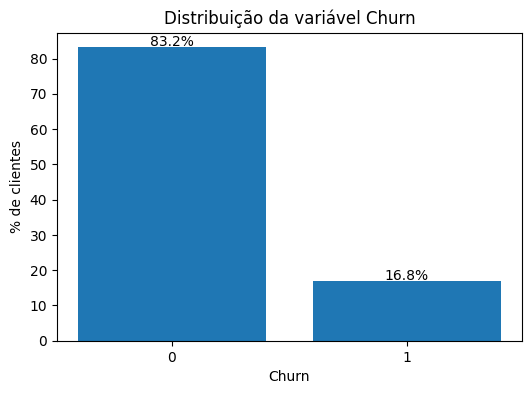

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(churn_distribution["churn"].astype(str), churn_distribution["pct"])

ax.set_title("Distribuição da variável Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("% de clientes")

for index, row in churn_distribution.iterrows():
    ax.text(index, row["pct"] + 0.5, f"{row['pct']:.1f}%", ha="center")

plt.show()

In [16]:
df_clean = df.copy()

before_rows = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after_rows = df_clean.shape[0]

print("Linhas antes:", before_rows)
print("Linhas depois:", after_rows)
print("Duplicatas removidas:", before_rows - after_rows)

if target_col in df_clean.columns:
    df_clean = df_clean.dropna(subset=[target_col])
    df_clean[target_col] = df_clean[target_col].astype(int)

numeric_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=["number"]).columns.tolist()

for col in ["customer_id", target_col]:
    if col in numeric_cols:
        numeric_cols.remove(col)

print("Colunas numéricas para tratamento:")
print(numeric_cols)

print("\nColunas categóricas para tratamento:")
print(categorical_cols)

Linhas antes: 5630
Linhas depois: 5630
Duplicatas removidas: 0
Colunas numéricas para tratamento:
['tenure', 'city_tier', 'warehouse_to_home_km', 'hours_spent_on_app', 'number_of_devices_registered', 'satisfaction_score', 'number_of_address', 'complained', 'order_amount_hike_from_last_year', 'coupons_used', 'order_count', 'days_since_last_order', 'cashback_amount']

Colunas categóricas para tratamento:
['preferred_login_device', 'preferred_payment_mode', 'gender', 'preferred_order_category', 'marital_status']


Tratar valores nulos

In [17]:
missing_before = df_clean.isna().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("Valores nulos antes do tratamento:")
display(missing_before)

for col in numeric_cols:
    if df_clean[col].isna().sum() > 0:
        df_clean[f"{col}_was_missing"] = df_clean[col].isna().astype(int)
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

for col in categorical_cols:
    if df_clean[col].isna().sum() > 0:
        df_clean[f"{col}_was_missing"] = df_clean[col].isna().astype(int)
        df_clean[col] = df_clean[col].fillna("unknown")

missing_after = df_clean.isna().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

print("Valores nulos depois do tratamento:")
display(missing_after)

Valores nulos antes do tratamento:


,0
days_since_last_order,307
order_amount_hike_from_last_year,265
tenure,264
order_count,258
coupons_used,256
hours_spent_on_app,255
warehouse_to_home_km,251


Valores nulos depois do tratamento:


,0


In [19]:
#Salvar base limpa no drive
clean_path = PROCESSED_DIR / "shopmais_churn_clean.csv"

df_clean.to_csv(clean_path, index=False, encoding="utf-8")

print("Base limpa salva em:")
print(clean_path)

print("\nDimensão final:")
print(df_clean.shape)

Base limpa salva em:
/content/drive/MyDrive/portfolio/shopmais-churn-eda/data/processed/shopmais_churn_clean.csv

Dimensão final:
(5630, 27)


## Auditoria inicial dos dados

A base possui 5.630 clientes e 20 variáveis, incluindo informações de relacionamento, comportamento de compra, uso do aplicativo, reclamações, satisfação e churn.

A taxa geral de churn identificada foi de 16,84%, com 948 clientes em churn e 4.682 clientes retidos. Essa taxa será usada como linha de base para comparar segmentos de clientes ao longo da análise.

Não foram encontradas duplicatas exatas na base, o que indica boa integridade inicial dos registros.

Foram identificados valores ausentes em variáveis numéricas relevantes, como tenure, distância do centro de distribuição, horas gastas no aplicativo, quantidade de pedidos, cupons utilizados e dias desde o último pedido. Como o percentual de ausência é moderado, entre aproximadamente 4,4% e 5,5%, será adotada uma estratégia conservadora de imputação pela mediana, acompanhada da criação de variáveis indicadoras de ausência.

Essa abordagem preserva os registros da base e evita perda desnecessária de clientes na análise.

In [20]:
for col in numeric_cols:
    missing_count = df_clean[col].isna().sum()

    if missing_count > 0:
        df_clean[f"{col}_was_missing"] = df_clean[col].isna().astype(int)

        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

        print(f"{col}: {missing_count} nulos preenchidos com mediana = {median_value}")

for col in categorical_cols:
    missing_count = df_clean[col].isna().sum()

    if missing_count > 0:
        df_clean[f"{col}_was_missing"] = df_clean[col].isna().astype(int)
        df_clean[col] = df_clean[col].fillna("unknown")

        print(f"{col}: {missing_count} nulos preenchidos com 'unknown'")

In [21]:
remaining_missing = df_clean.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if remaining_missing.empty:
    print("Não há mais valores nulos na base limpa.")
else:
    print("Ainda existem valores nulos:")
    display(remaining_missing)

Não há mais valores nulos na base limpa.


In [22]:
print("Dimensão original:", df.shape)
print("Dimensão após limpeza:", df_clean.shape)

new_columns = [col for col in df_clean.columns if col.endswith("_was_missing")]

print("\nFlags de ausência criadas:")
for col in new_columns:
    print("-", col)

Dimensão original: (5630, 20)
Dimensão após limpeza: (5630, 27)

Flags de ausência criadas:
- tenure_was_missing
- warehouse_to_home_km_was_missing
- hours_spent_on_app_was_missing
- order_amount_hike_from_last_year_was_missing
- coupons_used_was_missing
- order_count_was_missing
- days_since_last_order_was_missing


In [23]:
clean_path = PROCESSED_DIR / "shopmais_churn_clean.csv"

df_clean.to_csv(clean_path, index=False, encoding="utf-8")

print("Base limpa salva em:")
print(clean_path)

print("\nDimensão final:")
print(df_clean.shape)

Base limpa salva em:
/content/drive/MyDrive/portfolio/shopmais-churn-eda/data/processed/shopmais_churn_clean.csv

Dimensão final:
(5630, 27)


## Decisões de limpeza

A base não apresentou duplicatas exatas, portanto nenhum registro foi removido por duplicidade.

Os valores ausentes estavam concentrados em variáveis numéricas e representavam uma parcela moderada da base. Para evitar perda de registros, foi aplicada imputação pela mediana em cada variável numérica com ausência.

Além da imputação, foram criadas variáveis indicadoras com sufixo `_was_missing`. Essas variáveis preservam a informação de que determinado valor estava ausente originalmente, permitindo que análises posteriores identifiquem se a ausência de dados também está associada ao churn.

A base limpa foi salva em `data/processed/shopmais_churn_clean.csv` e será utilizada nas próximas etapas de engenharia de features e análise exploratória orientada a negócio.